# Generalized SVGD

In [57]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from generalized_svgd import GeneralizedSVGD

import jax
from jax import random

# KGD kernel :  IMQ   : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$. 
# SVGD kernel : Gaussian  : $m(x,y) = e^{-\|x-y\|^2/(2\sigma_m^2)}$.

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [58]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)


G_SVGD= GeneralizedSVGD(q_0,L,k,m,dm)

In [68]:
T = 500
n = 50
d = 2
Eta = [0.005,0.01,0.05,0.1,0.5,1.0,2.0,3.0,3.5,4.0,4.5]
n_sim = 2

KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100 + sim)  # Clé pseudo-aléatoire
        shape = (n, d)
        X0 = random.normal(key,shape) + 5* jnp.ones((n,d))

        KGD_values, F_P_values, all_particles = G_SVGD.run_particles(eta,T,X0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])
        

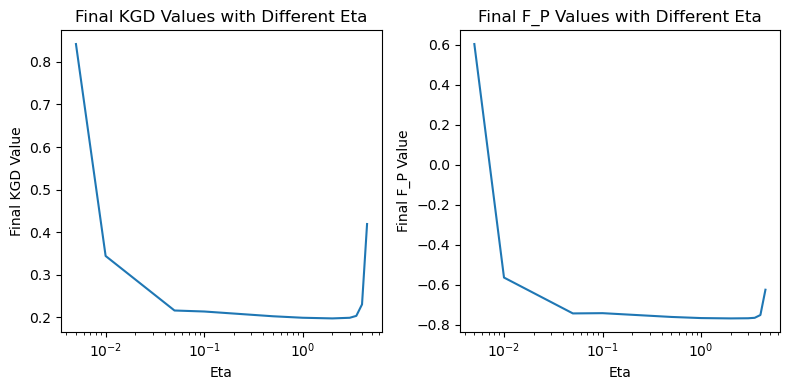

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns, adjust figure size

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
#axes[0].set_yscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
#axes[1].set_yscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [67]:
KGD_fin

Array([0.8419719 , 0.3439554 , 0.21580139, 0.2134668 , 0.20226002,
       0.19876325, 0.19723885, 0.19870049, 0.20317264, 0.2301199 ,
              nan,        nan,        nan,        nan], dtype=float32)

In [22]:
# for e in range(len(Eta)):
#     plt.figure(figsize=(6, 6))
#     plt.title(f'Particles at Final Time Step for Eta={Eta[e]}')
#     y = np.random.randn(n,d) * jnp.sqrt(2)
#     plt.scatter(y[:,0], y[:,1], label='gaussian', alpha=0.5,marker = "x")
#     plt.scatter(all_particles_fin[e,:,0], all_particles_fin[e,:,1], label=f'Eta={Eta[e]}', alpha=0.5)
#     plt.legend()

# 2. Linear + Quadratic term 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x) + \int \int w(x,x') \ d Q(x) d Q(x)$, with $v(x) = 1/2 \|x\|^2$ and $w(x,x') = x^Tx'$.

<!-- if w= 0
F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->

In [103]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2  *jnp.pi)**d)
def v(x):
    return -1/4 * jnp.linalg.norm(x,axis = 1)**2
def w(X):
    _X = jax.lax.stop_gradient(X).T
    return jnp.dot(X,_X)
def L(X):
     return np.mean(v(X)) + np.mean(w(X))

sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

In [115]:
T = 500
n = 10 
d = 2
Eta = [0.01,0.05,0.1,0.2,0.5,1.0,1.1,1.2,1.3,1.4]
#Eta = np.logspace(-3, 0, 10)
#X0 = jnp.random.randn(n, d)+ np.array([-5, 5])
n_sim = 3
KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100)  
        shape = (n, d)
        X0 = random.normal(key,shape) + 5* jnp.ones((n,d))
        
        KGD_values, F_P_values, all_particles = G_SVGD.run_particles(eta,T,X0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

In [133]:
from jax.scipy.stats import gaussian_kde
kernel = gaussian_kde(X0.T)
X00 = jnp.array([kernel.resample(random.PRNGKey(17 + i)) for i in range(n)])
print(jnp.array([kernel.evaluate(X00[i])for i in range(n)]))

#jnp.expand_dims(X0,axis = 0) - jnp.expand_dims(X00.T,axis = 1)
#print(kernel)

[[0.09719449]
 [0.13054264]
 [0.16600625]
 [0.16174707]
 [0.08623464]
 [0.06210342]
 [0.11765065]
 [0.16355376]
 [0.02390954]
 [0.16595602]]


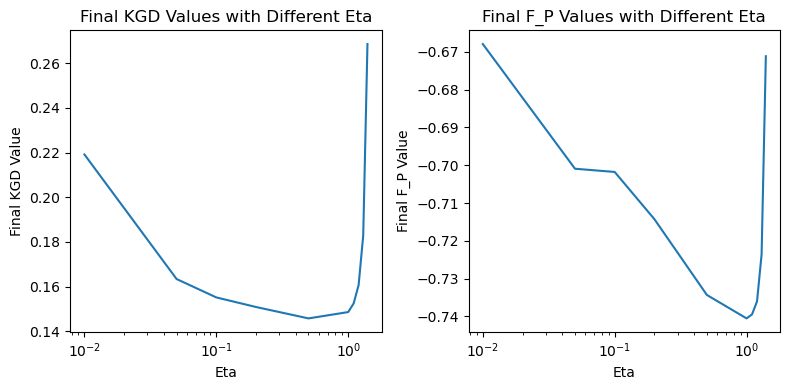

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')


plt.tight_layout()
plt.show()

# 3. MMD

### a) Q_1 is a Gaussian
- $\mathcal{L}(Q) = \frac{\gamma}{2} \textrm{MMD}(Q,Q_1)^2$
- $Q_1 = \mathcal{N}(\mu,\Sigma)$ where $\mu = (5,5)$, $\Sigma = I_d$
- Gaussian kernel in the MMD: $l(x,x') = \exp(-\frac{\|x-x'\|^2}{2 \sigma_l^2})$

In [77]:
c = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y))) #(x-y,x-y)/(2*c**2))

x2 = jnp.array([5,5])
def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/(2*4)) / jnp.sqrt((2* 4  *jnp.pi)**d)

sigma_l = 3.0
l = lambda x,y : ker.k_gauss(x,y,sigma_l) #Gram matrix for gaussian kernel = shape (n,m)

d = 2
Cov = np.diag(jnp.ones(d))
n1 = 70
mu = 5*np.ones(d)

key = random.PRNGKey(98)  
shape1 = (n1, d)
X1 = random.multivariate_normal(key,mu,Cov,n1)

gamma = 10
def L(X):
    _X = jax.lax.stop_gradient(X)
    return gamma/2 * (np.mean(l(X,_X)) - 2 * np.mean(l(X,X1)) + np.mean(l(X1,X1)))


sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

In [78]:
T = 500
n = 50
#Eta = #[0.01,0.05,0.1]#,0.2,0.5,1.0,2.0,3.0,5.0,10.0,20.0,30.0,50.0,100.0]
Eta = np.logspace(-3,1,10)
n_sim = 1

KGD_fin = jnp.zeros(len(Eta))
F_P_fin = jnp.zeros(len(Eta))
all_particles_fin = jnp.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100+sim)  
        shape = (n, d)
        X0 = random.normal(key,shape) + jnp.array([-5,5])

        KGD_values, F_P_values, all_particles = G_SVGD.run_particles(eta,T,X0)
        KGD_fin = KGD_fin.at[e].set(KGD_fin[e] + 1/n_sim * KGD_values[-1])
        F_P_fin = F_P_fin.at[e].set(F_P_fin[e] + 1/n_sim * F_P_values[-1])
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


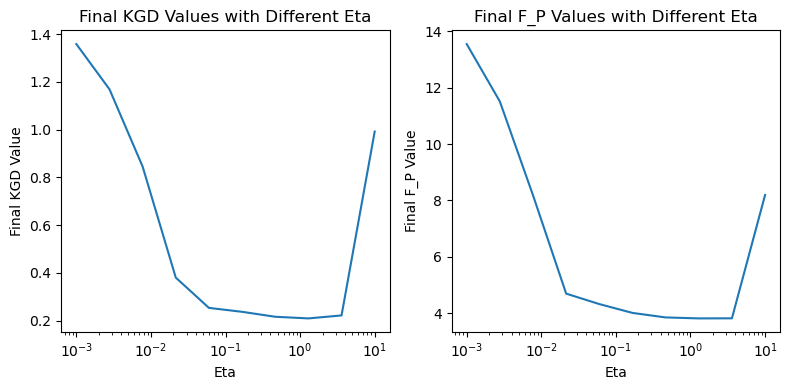

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')


axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')


plt.tight_layout()
plt.show()

# 4 MFNN : $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$. The learning function $\psi$ is a two layer neural network. 

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from generalized_svgd import GeneralizedSVGD
import jax_kernels as ker
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

In [90]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(rng, input_dim, hidden_dim):
    rng1, rng2 = random.split(rng)
    params = {
        'W1': random.normal(rng1, (hidden_dim, input_dim)) * 1.0,
        'b1': jnp.zeros(hidden_dim),
        'W2': random.normal(rng2, (1, hidden_dim)) * 1.0,
        'b2': jnp.zeros(1),
    }
    return params

def forward(params, z):
    h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
    y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
    return y.squeeze()


In [91]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.normal(key_z, (N, s))  # Features z ∈ ℝ^s

    #explanation function
    def f(z):
        return jnp.sin(Z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N=300, noise_std=0.01)

$k$, $q_0$ and $\mathcal{L}$

In [92]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/2) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
hidden_dim = 20
params = init_params(key, s, hidden_dim)  
flat_params, unravel_fn = ravel_pytree(params)
lambd = 0.1


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
    return E
def L(X):
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return jnp.mean((Esp_forward - Y) ** 2) + lambd * 1/n * jnp.sum(X ** 2)


sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)
 
G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)    

In [93]:
T = 300
n = 20

Eta = jnp.logspace(-4,-2,8)
key = random.PRNGKey(14)
X_list = [init_params(random.fold_in(key, i), s, hidden_dim) for i in range(n)]
flat_X_list = [ravel_pytree(p)[0] for p in X_list]  # flatten
X0 = jnp.stack(flat_X_list)
d = len(X0[0])

n_sim = 1

KGD_fin = np.zeros(len(Eta))
F_P_fin = np.zeros(len(Eta))
all_particles_fin = np.zeros((len(Eta), n, d))

for e,eta in enumerate(Eta):
    for sim in range(n_sim):
        key = random.PRNGKey(100 + sim)
        X_list = [init_params(random.fold_in(key, i), s, hidden_dim) for i in range(n)]
        flat_X_list = [ravel_pytree(p)[0] for p in X_list]  # flatten
        X0 = jnp.stack(flat_X_list)
        KGD_values, F_P_values, all_particles = MFLD.run_particles(eta,T,X0)
        KGD_fin[e] += 1/n_sim * KGD_values[-1]
        F_P_fin[e] += 1/n_sim * F_P_values[-1]
    all_particles_fin[e] = all_particles[-1]



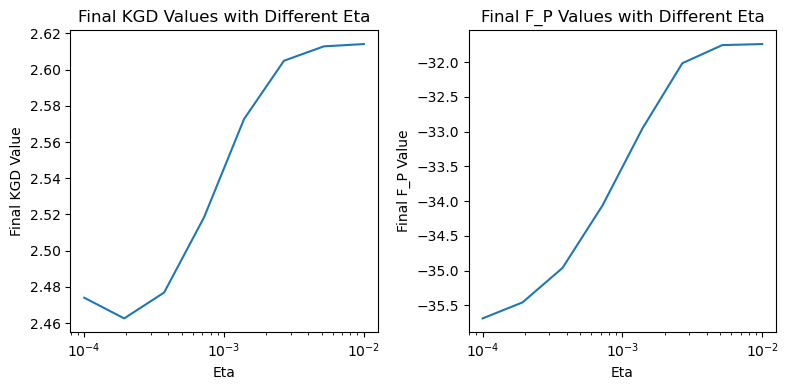

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns, adjust figure size

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin)
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()